# Sensors

*The BNO085 on SPI2 and the A1335 on SPI4, read through the board's own poll loops: what each reports, the three things the IMU refuses over, and whether there is a magnet.*

**Abstract.** Two parts sit on the board's SPI buses behind the same rail as the analog front end: a BNO085 sensor hub on SPI2 and an A1335 magnetic angle sensor on SPI4. The firmware polls each from its main loop into a shared record and a host reads that record; driving either bus directly needs the loop held. This notebook runs both on the stand-in, and on a board with the knob flipped: the rail and the parts list that says what it powers, the IMU's four pins, its wake and four raw bytes off the bus, a rotation vector enabled at 20 ms with the three vectors beside it, the attitude drawn as the BOARD ATTITUDE page draws it, the A1335's six registers decoded into an angle, a die temperature and a field, the dial the SHAFT ANGLE page draws, and both parts riding one acquisition record at 50 a second. What it measures: the monotonic update counter between two reads, the gravity, rate and field vectors and their magnitudes, ANG's twelve bits as degrees, FIELD in gauss against the 300 to 1000 G the datasheet recommends, and the shaft's rate off record timestamps rather than a wall clock. What a reader takes to the bench: the three refusals - AFE_ON low, the poll loop running, a part still announcing itself - are the board's and the stand-in shows none of them; FIELD near 2 G is no magnet; and TSEN is the part's own die, not the board.

## 1 Setup

In [1]:
SIMULATED = True          # False, and PORT, at the bench
PORT = 'COM4'

In [2]:
from coaxial import Coaxial63100

device = Coaxial63100(port=PORT, simulated_device=SIMULATED).open()
print(device)

<Coaxial63100 Simulated SIMULATED>


## 2 The rail both parts hang on

AFE_ON powers the ADC reference, the BNO085 and the A1335. `0x6D` kind 4 is the parts list and `power` is its column, so the answer comes off the bus and not from a document. Unpowered, the BNO085 still drives MISO, resets and advertises - a valid 276-byte advertisement reads back - while acting on no write, so every symptom presents as SPI, and a day went there before the supply was checked (FINDINGS); `Board_ImuInit` refuses while PB2 is low, the first of the three refusals. `daq.enable()` takes this session's reference on the rail, which `close()` releases; `settled()` waits for each loop to say `running`, because a write before that is refused, not queued.

In [3]:
from coaxial.errors import RigError

parts = device.system.channel_map()['parts']
powered = [p for p in parts if p['power'] == 'AFE_ON']
for p in powered:
    print('%-16s %-24s %-16s %s' % (p['name'], p['what'], p['where'], p['state']))
imu = device.imu
angle = device.angle
rail = device.afe.state()
try:
    with imu.configuring():
        answer = imu.product_id()
    print('rail on=%s: product id answered, version %s, reset cause %s'
          % (rail['on'], answer['sw_version'], answer['reset_cause_name']))
except RigError as exc:
    print('rail on=%s: refused - %s' % (rail['on'], exc))

BNO085           9-axis IMU, SHTP         SPI2, U13        ready
A1335            magnetic angle sensor    SPI4, U14        ready
NTC              thermistor               ADC3             ready
DC link divider  49.9k/2.2k, 78.15 V FS   ADC              ready
rail on=False: product id answered, version simulated, reset cause power on reset


In [4]:
daq = device.daq
daq.enable()
rail = device.afe.state()
print(rail)
print('IMU loop running:', imu.settled(), ' angle loop running:', angle.settled())

{'on': True, 'pe15': False, 'users': ['host']}
IMU loop running: True  angle loop running: True


On the stand-in the product id answered with the rail off: it has no rail to lose, which is the one refusal it cannot show. On a board the first line is the refusal, and `users` after `enable()` names this session as a holder of the rail.

## 3 SPI2 belongs to the poll loop

Every operation that drives SPI2 - `product_id`, `feature`, `reset`, `probe`, `write`, `pins` - is refused while the loop runs: both would be masters on one bus, and a cargo split between them is the second refusal. Measured 2026-08-29, it read as a dead part for an hour, through a reflash to rule out a regression that was never there (FINDINGS). `configuring()` holds the loop for the block and resumes however it ends. Inside it: the product id; the four pins driven and released, `bits` 15 a pin that followed the MCU every way and `held` one something else holds; the wake test in milliseconds; four raw bytes off the bus; and a reset, which answers how many cargoes it produced.

In [5]:
try:
    print('while running: answered, version', imu.product_id()['sw_version'])
except RigError as exc:
    print('while running: refused -', exc)
with imu.configuring():
    print('in the block:', imu.state()['loop'])
    ident = imu.product_id()
    pins = imu.pins()
    wake = imu.wake_test()
    probe = imu.probe()
    drained = imu.reset()
print('after:', imu.state()['loop'], ' settled:', imu.settled())
print(ident)
for p in pins:
    print('  %-5s %-10s bits %2d  held %s' % (p['pin'], p['signal'], p['bits'], p['held']))
print('wake   %s ms' % wake)
print('probe  %s at %d bit/s off a %d Hz kernel'
      % (probe['raw'].hex(' '), probe['bitrate_hz'], probe['kernel_hz']))
print('reset  produced %d cargoes' % drained)

while running: answered, version simulated
in the block: held
after: running  settled: True
{'reset_cause': 1, 'reset_cause_name': 'power on reset', 'sw_version': 'simulated', 'sw_part': 0, 'sw_build': 0, 'sw_patch': 0}
  PB12  NSS/H_CSN  bits 15  held False
  PB13  SCK        bits 15  held False
  PB14  MISO       bits 15  held False
  PB15  MOSI       bits 15  held False
wake   0 ms
probe  00 00 00 00 at 1484375 bit/s off a 190000000 Hz kernel
reset  produced 3 cargoes


Bits 15 on all four pins is SPI2 with nothing else on it. `00 00 00 00` off the bus is a part present and idle; `ff ff ff ff` is one absent or in reset. Three cargoes from a reset are the advertisement and the two announcements - what a write on top of them is lost under. The stand-in answered the product id with the loop running; a board refuses it.

## 4 The rotation vector

Set Feature: report 0x05 is the rotation vector, the interval in microseconds, 0 disables it. A write into a part still announcing itself after a reset is a write nobody acts on - with the three announcements queued every write came back SERVER DEVICE FAILURE - the third refusal, and why the firmware drains first, three empty reads a couple of milliseconds apart being quiet (FINDINGS). The interval goes out big-endian like every integer on this wire; sent little-endian, 60 000 us arrived as 27 minutes. The first report lands one interval after the write, so the wait below is in 20 ms steps until the record holds one; two reads after that show `updates` advancing and the quaternion with it.

In [6]:
import time

from coaxial.devices.imu import ROTATION_VECTOR

imu.configure({ROTATION_VECTOR: 20000})
waited = 0.0
while imu.read() is None and waited < 2.0:
    time.sleep(0.02)                    # one report interval
    waited += 0.02
first = imu.state()
second = imu.state()
for st in (first, second):
    q = st['quaternion']
    print('%-8s updates %6d  %s, %s accuracy  %s'
          % (st['loop'], st['updates'], st.get('name'), st.get('accuracy'),
             None if q is None else {k: round(v, 3) for k, v in q.items()}))
print('feature asked:', first['feature'], ' first report after %.2f s' % waited)
print('error %s, last fault %s (id %d), cargoes %d, errors %d'
      % (second['error'], second['last_fault'], second['last_fault_id'],
         second['cargoes'], second['errors']))

running  updates    102  rotation vector, high accuracy  {'i': 0.073, 'j': 0.146, 'k': -0.011, 'real': 0.986}
running  updates    119  rotation vector, high accuracy  {'i': 0.085, 'j': 0.17, 'k': -0.015, 'real': 0.982}
feature asked: {'report_id': 5, 'interval_us': 20000, 'pending': False}  first report after 0.00 s
error none, last fault none (id 0), cargoes 119, errors 0


## 5 The three vectors

Since MINOR 6 the accelerometer, gyroscope and magnetometer ride the same reply, each with its own `have`: a feature nobody enabled is None, not zero, because zero is a legal reading and a still part must not be confused with a silent one. Enabled at 20 ms each, they come back with an accuracy word, a unit and the counts beside the value - Q8 m/s^2, Q9 rad/s, Q4 uT, the Q point kept in `coaxial.devices.imu` and not in the firmware, the same division the ADC channels keep. The magnitudes are the check: one g at rest, no rate, and a field inside the Earth's 25 to 65 uT.

In [7]:
import math

from coaxial.devices.imu import ACCELEROMETER, GYROSCOPE, MAGNETIC_FIELD

VECTORS = ('accelerometer', 'gyroscope', 'magnetometer')
before = imu.state()
for name in VECTORS:
    print('%-14s %s' % (name, before[name]))
imu.configure(dict.fromkeys((ACCELEROMETER, GYROSCOPE, MAGNETIC_FIELD), 20000))
vectors = imu.state()
while any(vectors[n] is None for n in VECTORS) and waited < 4.0:
    time.sleep(0.02)                    # one report interval
    waited += 0.02
    vectors = imu.state()
magnitude = {}
for name in VECTORS:
    v = vectors[name]
    magnitude[name] = math.sqrt(sum(c * c for c in v['value'].values()))
    print('%-14s %-5s %-6s x %8.3f  y %8.3f  z %8.3f  |v| %7.3f  counts %s'
          % (name, v['accuracy'], v['unit'], v['value']['x'], v['value']['y'],
             v['value']['z'], magnitude[name], v['counts']))

accelerometer  None
gyroscope      None
magnetometer   None
accelerometer  high  m/s^2  x    0.003  y    0.006  z    9.808  |v|   9.808  counts {'x': 0, 'y': 1, 'z': 2510}
gyroscope      high  rad/s  x    0.041  y    0.010  z    0.005  |v|   0.043  counts {'x': 21, 'y': 5, 'z': 2}
magnetometer   high  uT     x   22.017  y   -2.995  z   40.964  |v|  46.602  counts {'x': 352, 'y': -47, 'z': 655}


## 6 The board at that attitude

The board at the quaternion, as the BOARD ATTITUDE page draws it: `coaxial.draw.orientation.render` in its wireframe, colour on, and `coaxial.draw.ansi.image` rasterising the braille the way the terminal shows it - a picture is judged in a raster, not in glyph counts. The part sends i, j, k, real in that order, which is not the order most quaternion maths is written in, and `render` takes them that way. The stand-in tumbles; a board lying on the bench draws flat, and one in the hand tilts the picture.

{'i': 0.119, 'j': 0.241, 'k': -0.03, 'real': 0.963}


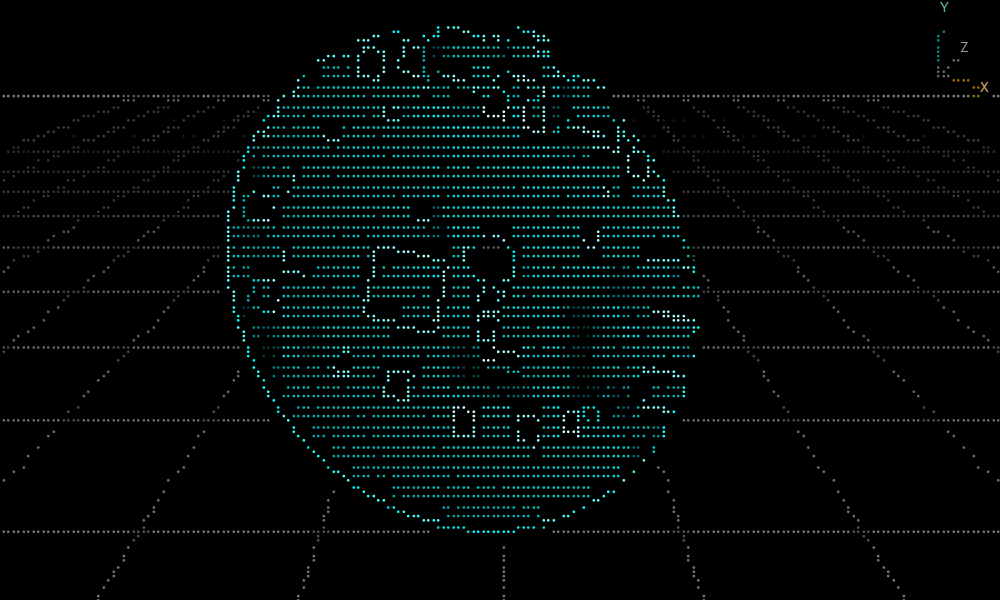

In [8]:
from coaxial.draw import ansi, orientation

q = imu.state()['quaternion']
print({k: round(v, 3) for k, v in q.items()})
ansi.image(orientation.render((q['i'], q['j'], q['k'], q['real']), 100, 30, wire=True, colour=True))

## 7 The A1335: six registers

The A1335 sits on SPI4 behind the same rail. Its loop reads one register, ANG unless `poll_register` says otherwise, into shared memory; `state()` reads that record and touches no SPI, because a cargo per request cost 45 ms and caught one frame in eight. The register map comes from a reference implementation, because the datasheet in this tree defers it to a programming manual that is not here: ANG 0x20, STA 0x22, ERR 0x24, XERR 0x26, TSEN 0x28, FIELD 0x2A. A read is two 20-bit frames and needs the loop held; the CRC is reported, not checked. The twelve low bits are the reading, the four above are flags: ANG counts 360/4096 of a turn, TSEN eighths of a kelvin, FIELD's count is the gauss.

In [9]:
from coaxial.devices.angle import ANG, FIELD, TSEN, counts, degrees, gauss, kelvin
from coaxial.devices.scaling import KELVIN_AT_ZERO_C

st = angle.state()
print({k: st.get(k) for k in ('loop', 'updates', 'errors', 'register_name', 'value', 'degrees', 'crc')})
print(angle.clock(), angle.state()['register_name'])
with angle.configuring():
    print('in the block:', angle.state()['loop'])
    got = {reg: angle.peek(reg) for reg in (0x20, 0x22, 0x24, 0x26, 0x28, 0x2A)}
print('after:', angle.state()['loop'])
for r in got.values():
    print('%-5s 0x%04X  data %4d  flags 0x%X  crc %d'
          % (r['register_name'], r['value'], counts(r['value']), r['value'] >> 12, r['crc']))
ang, tsen, field = (got[reg]['value'] for reg in (ANG, TSEN, FIELD))
print('angle  %.2f deg' % degrees(ang))
print('die    %.1f K = %.1f C' % (kelvin(tsen), kelvin(tsen) - KELVIN_AT_ZERO_C))
print('field  %.0f G' % gauss(field))

{'loop': 'running', 'updates': 74, 'errors': 0, 'register_name': 'ANG', 'value': 21099, 'degrees': 54.404296875, 'crc': 0}
{'kernel_hz': 118750000, 'bitrate_hz': 1855468} {'register': 32, 'register_name': 'ANG'}
in the block: held
after: running
ANG   0x526B  data  619  flags 0x5  crc 0
STA   0x8000  data    0  flags 0x8  crc 0
ERR   0x8000  data    0  flags 0x8  crc 0
XERR  0x8000  data    0  flags 0x8  crc 0
TSEN  0xF951  data 2385  flags 0xF  crc 0
FIELD 0xE17C  data  380  flags 0xE  crc 0
angle  54.40 deg
die    298.1 K = 25.0 C
field  380 G


The stand-in reports a magnet in place at 380 G and a die as warm as its thermal stand-in's board node. A bare board reads about 2 G with no magnet, and 300 to 1000 G is the range the datasheet recommends.

## 8 The dial

The three registers as the SHAFT ANGLE page draws them: the face at ANG with the reading swept from zero, the die's temperature on the part's -40 to 150 C to the left, the field on 0 to 1200 G to the right - green inside the recommended band, red with no magnet. Below a few tens of gauss the face draws the instrument and no needle, rather than a confident one at a number that means nothing. `coaxial.draw.dial` is pure; `coaxial.draw.ansi.image` rasterises it.

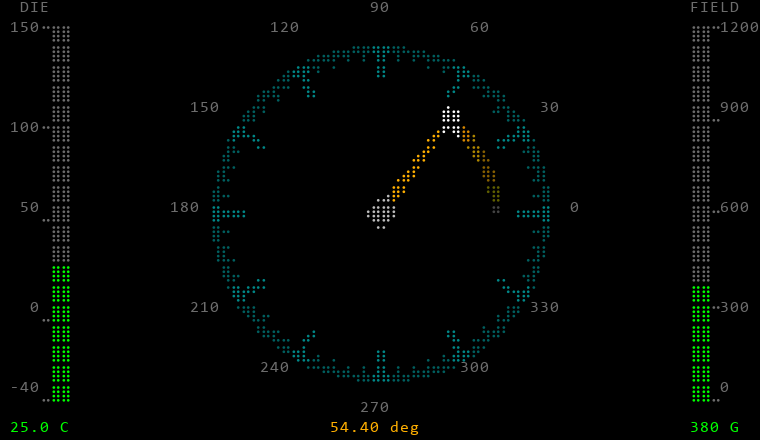

In [10]:
from coaxial.draw import dial

ansi.image(dial.instrument(degrees(ang), gauss(field), kelvin(tsen), colour=True))

## 9 Both parts in one record

Since MINOR 7 the sensor fields ride any software-clocked record as four-word snapshots beside the sums, latched with the currents they were taken with: `orientation` is the quaternion's Q14 counts, `shaft angle` is ANG's value, its CRC, the register and `have`. A record needs one analog channel, so the NTC makes it. The board counts cycles, not time: `set_time_from_pc` ties its counter to the host's clock, and a record read before that carries no stamp. Two seconds at 50 records a second; `frame(scaled=True)` adds `shaft angle (deg)` and the four `orientation (unit)` columns through the subsystems' own conversions. The shaft's rate comes off the record stamps and not a wall clock, and `have` says the snapshot was there in every record.

In [11]:
daq = device.daq
print(device.set_time_from_pc(reference='pc'))
layout = daq.configure('NTC', 'shaft angle', 'orientation', sample_rate=50)
print(layout['sensors'])
daq.start()
run = daq.read(100)
daq.stop()
df = daq.frame(run, index='elapsed', scaled=True)
present = int(df['shaft angle have'].sum())
print('%d records, stride %d bytes; shaft snapshot present in %d of %d'
      % (len(run), layout['stride'], present, len(df)))
print(run[0]['sensors'])
df[['shaft angle (deg)', 'orientation i (unit)', 'orientation j (unit)',
    'orientation k (unit)', 'orientation real (unit)']].describe().round(3)

<Sync 474.994302 MHz (-12.0 ppm vs pc, floor 0.2 ppm), reference +/- 1 us>
[{'bit': 0, 'words': 4, 'signal': 'orientation'}, {'bit': 4, 'words': 4, 'signal': 'shaft angle'}]


100 records, stride 35 bytes; shaft snapshot present in 100 of 100
{'orientation': (2125, 4330, -588, 15646), 'shaft angle': (22154, 0, 32, 1)}


,shaft angle (deg),orientation i (unit),orientation j (unit),orientation k (unit),orientation real (unit)
count,100.000,100.000,100.000,100.000,100.000
mean,177.536,-0.110,0.525,-0.505,0.186
std,17.713,0.383,0.207,0.234,0.427
min,147.129,-0.882,0.094,-0.770,-0.272
25%,163.059,-0.431,0.359,-0.716,-0.223
50%,177.759,0.058,0.568,-0.568,0.063
75%,192.041,0.223,0.716,-0.327,0.579
max,207.510,0.272,0.770,-0.036,0.955


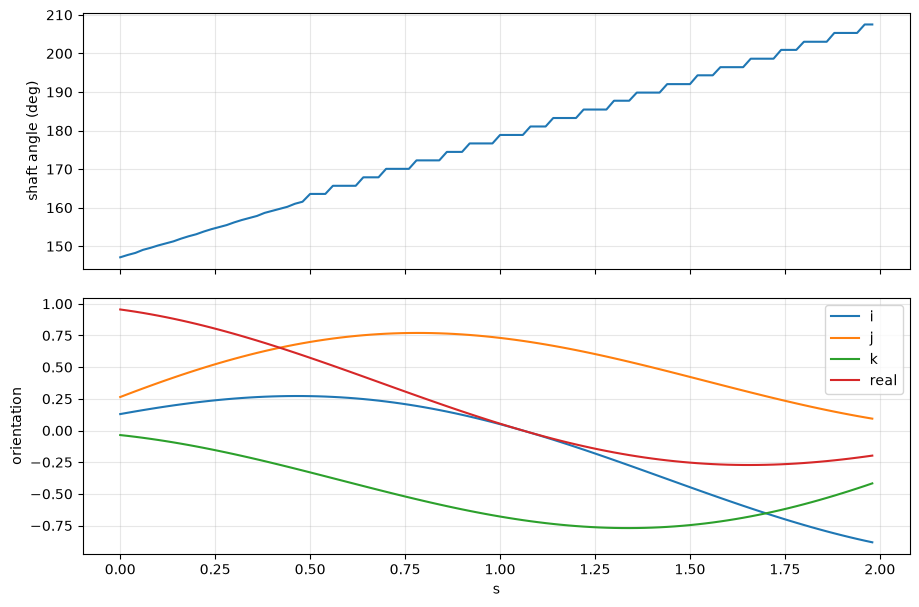

In [12]:
from coaxial.draw.figures import figure, show

axes = ['orientation %s (unit)' % w for w in ('i', 'j', 'k', 'real')]
fig, (top, bottom) = figure(rows=2, sharex=True)
top.plot(df.index, df['shaft angle (deg)'])
top.set_ylabel('shaft angle (deg)')
for column in axes:
    bottom.plot(df.index, df[column], label=column.split()[1])
bottom.set_ylabel('orientation')
bottom.legend(loc='upper right')
bottom.set_xlabel('s')
show(fig)

In [13]:
turned = [df['shaft angle (deg)'].iloc[0]]
for reading in df['shaft angle (deg)'].iloc[1:]:
    turned.append(turned[-1] + (reading - turned[-1] % 360.0 + 180.0) % 360.0 - 180.0)
span = df.index[-1] - df.index[0]
rate = (turned[-1] - turned[0]) / span
norm = (df[axes] ** 2).sum(axis=1) ** 0.5
print('shaft  %.2f deg over %.2f s = %.1f deg/s' % (turned[-1] - turned[0], span, rate))
print('|q|    %.4f to %.4f over %d records' % (norm.min(), norm.max(), len(norm)))
imu.configure(dict.fromkeys((ROTATION_VECTOR, ACCELEROMETER, GYROSCOPE, MAGNETIC_FIELD), 0))
imu_final = imu.state()
angle_final = angle.state()
print('features off; IMU loop %s, angle loop %s' % (imu_final['loop'], angle_final['loop']))

shaft  60.38 deg over 1.98 s = 30.5 deg/s
|q|    0.9999 to 1.0000 over 100 records
features off; IMU loop running, angle loop running


In [14]:
device.close()
print(device)

<Coaxial63100 Simulated SIMULATED>


## 10 Conclusions

In [15]:
print('1. rail       AFE_ON powers %d of %d listed parts (%s); on=%s, users %s'
      % (len(powered), len(parts), ', '.join(p['name'] for p in powered),
         rail['on'], rail['users']))
print('2. SPI2       %d pins, %d held; wake %s ms; bus %s; reset produced %d cargoes'
      % (len(pins), sum(p['held'] for p in pins), wake, probe['raw'].hex(' '), drained))
print('3. rotation   report 0x%02X at %d us, pending %s; first report after %.2f s; '
      'updates +%d between two reads; %s accuracy; |q| %.4f'
      % (first['feature']['report_id'], first['feature']['interval_us'],
         first['feature']['pending'], waited, second['updates'] - first['updates'],
         second['accuracy'],
         math.sqrt(sum(v * v for v in second['quaternion'].values()))))
print('4. vectors    before enabling: %s; after: |a| %.2f m/s^2, |w| %.3f rad/s, |B| %.1f uT'
      % (', '.join(str(before[n]) for n in VECTORS), magnitude['accelerometer'],
         magnitude['gyroscope'], magnitude['magnetometer']))
print('5. A1335      ANG 0x%04X = %.2f deg; TSEN 0x%04X = %.1f K = %.1f C (%.3f K a count); '
      'FIELD 0x%04X = %.0f G, %s; CRC %d reported, not checked; SPI4 %.3f Mbit/s off %.2f MHz'
      % (ang, degrees(ang), tsen, kelvin(tsen), kelvin(tsen) - KELVIN_AT_ZERO_C, 1.0 / 8,
         field, gauss(field),
         'no magnet' if gauss(field) < dial.WEAK_GAUSS else 'a magnet in place',
         got[ANG]['crc'], angle.clock()['bitrate_hz'] / 1e6, angle.clock()['kernel_hz'] / 1e6))
print('6. record     %d records at 50/s, stride %d bytes; shaft %.2f deg over %.2f s = %.1f deg/s; '
      'snapshot in %d of %d; |q| %.4f to %.4f'
      % (len(run), layout['stride'], turned[-1] - turned[0], span, rate, present,
         len(df), norm.min(), norm.max()))
print('7. loops      IMU %s: updates %d, cargoes %d, errors %d, last fault %s (id %d); '
      'angle %s: updates %d, errors %d'
      % (imu_final['loop'], imu_final['updates'], imu_final['cargoes'], imu_final['errors'],
         imu_final['last_fault'], imu_final['last_fault_id'], angle_final['loop'],
         angle_final['updates'], angle_final['errors']))

1. rail       AFE_ON powers 4 of 10 listed parts (BNO085, A1335, NTC, DC link divider); on=True, users ['host']
2. SPI2       4 pins, 0 held; wake 0 ms; bus 00 00 00 00; reset produced 3 cargoes
3. rotation   report 0x05 at 20000 us, pending False; first report after 0.00 s; updates +17 between two reads; high accuracy; |q| 1.0000
4. vectors    before enabling: None, None, None; after: |a| 9.81 m/s^2, |w| 0.043 rad/s, |B| 46.6 uT
5. A1335      ANG 0x526B = 54.40 deg; TSEN 0xF951 = 298.1 K = 25.0 C (0.125 K a count); FIELD 0xE17C = 380 G, a magnet in place; CRC 0 reported, not checked; SPI4 1.855 Mbit/s off 118.75 MHz
6. record     100 records at 50/s, stride 35 bytes; shaft 60.38 deg over 1.98 s = 30.5 deg/s; snapshot in 100 of 100; |q| 0.9999 to 1.0000
7. loops      IMU running: updates 1972, cargoes 1972, errors 0, last fault none (id 0); angle running: updates 185, errors 0


The three refusals are the board's, and the stand-in shows none of them. **AFE_ON low**: the rail powers the part, not just the front end. Unpowered it still drives MISO, resets and advertises - a valid 276-byte advertisement reads back - while acting on no write, so every symptom presents as SPI; `Board_ImuInit` refuses while PB2 is low. **The poll loop running**: both driving SPI2 is two masters on one bus and a cargo split between them; `configuring()` holds and resumes, and the refusal read as a dead part for an hour on 2026-08-29 before the loop's state was asked (FINDINGS). **A part mid-sentence**: H_INTN stays asserted until everything queued is collected, so a write on top of a reset's three announcements loses both messages - SERVER DEVICE FAILURE. The firmware drains first, three empty reads a couple of milliseconds apart being quiet. The stand-in's wake answers in 0 ms every time; the board's answers in under a millisecond and then now and again not at all - twice in ten over eight seconds, and permanently after the part had been left alone for a few minutes - and releasing WAKE and asserting it again recovers it (FINDINGS).

`updates` is monotonic, so the same reading read twice is telling. On the stand-in it advances a fixed 17 a read for the IMU and 37 for the A1335, so a rate per second off it counts reads and nothing else, which is why the shaft's rate in conclusion 6 is taken off record timestamps: 30 degrees a second is the stand-in's invented turn, one every twelve seconds. `error` is the last poll's and clears on the next good read; `last_fault` is what a host polling at 5 Hz would never see. The three vectors each carry their own `have`, so a feature nobody enabled is None and not zero, and the Q points that turn their counts into m/s^2, rad/s and uT live in `coaxial.devices.imu` and nowhere else.

Every A1335 read is two frames: the address arrives on MOSI bits 17..12 while MISO has already shifted out bits 19..16, so the answer cannot be to the frame carrying the address - asking TSEN, FIELD, TSEN in turn returned the previous register's value every time. The first frame posts the address, the second clocks the answer out. The CRC is reported and not checked: the datasheet in this tree gives the field's width and not its polynomial, and checking against a guessed one would reject good readings. The register map came from a reference implementation rather than that datasheet, which is why the polled register is settable without a rebuild; the R/W bit's polarity was measured on this board, and read is 0 (FINDINGS).

FIELD says whether there is a magnet: the real board reads about 2 G with none, 300 to 1000 G is the recommended range, and the stand-in's 380 G is a magnet in place by construction. TSEN is the part's own die, not the board: it quantises at 0.125 K and is reset every time AFE_ON breaks; measured 2026-08-28 it fell 1.88 K during a run that warmed the board, and NTC minus TSEN read -0.74 C idle and +10.94 C switching, which is why the NTC is the thermal observer's reference and this is not (FINDINGS). Every conversion is one place - `coaxial.devices.angle` for the twelve bits, `coaxial.devices.imu` for the Q points - and the record's scaled columns in conclusion 6 come through the same ones (invariant 7).

**At the bench.** Flip `SIMULATED` and name the port. Section 2's first cell is then a refusal with the rail down and section 3's first line one with the loop running - the two the stand-in answered. Compare the pins against bits 15 on all four with nothing held, the wake against under a millisecond, and the raw bytes against `00 00 00 00`: `ff ff ff ff` is a part absent or in reset, and a reset that produces fewer than three cargoes did not come up. Wait on `settled()` after the rail comes up before any Set Feature - written straight after, it failed twice in a row. Read FIELD before believing ANG: about 2 G is no magnet and the dial draws no needle; 300 to 1000 G is the band. Compare conclusion 6's rate and quaternion norm against the shaft in the hand, and conclusion 7's counters against a second read a minute later - errors that climb are the link, a last fault that is not `none` is the part. The staircase in section 9's shaft trace is the stand-in making a block's records at one instant; a board latches each snapshot with its own sums. What the stand-in could not show: any of the three refusals, a CRC, a real field, a part that stops streaming, and a link that serves fewer than 50 records a second.

## References

* `host/coaxial/devices/imu.py` - the BNO085 host side: report lengths, Q points, and the refusal explained
* `host/coaxial/devices/angle.py` - the A1335 host side: the register map, the twelve bits as degrees, kelvin and gauss
* `host/coaxial/devices/sensor.py` - `PolledSensor`: `state`, `hold`, `resume`, `configuring`, `settled`
* `host/coaxial/simulated/sensors.py` - the stand-in this ran on: a BNO085 that tumbles and an A1335 that follows the simulated shaft
* `board/src/board_imu.c` - the SPI2 poll loop, the drain before a write, the refusal while PB2 is low
* `board/src/board_angle.c` - the SPI4 loop and the two-frame read
* `docs/PROTOCOL.md` - devices 0 and 1 on the wire; op 8's appended vectors (MINOR 6); the record's snapshots (MINOR 7)
* `docs/FINDINGS.md` - The AFE and the reference, The IMU, The A1335: what was measured and ruled out